# Analyzing and Predicting Luxury Watch Prices 


## Skills: Introduction to Programming

### Package setup
Install the required packages from the requirements file before running the notebook:

```bash
pip install -r requirements.txt
```

In [1]:
#Import the relevant libraries for data manipulation and visualization and prediction:

import datetime
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import sklearn.linear_model as lg 
from sklearn.model_selection import train_test_split
import category_encoders as ce
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import shap

#### Authors: Jan Nemeth, Daniel Kullmann, Timon Mata, Julian Kreiliger, Philipp Sajthy, Yannick Allmann

## Part 1: Dataset Loading 

In this section we will be loading the dataset of luxury watches we obtained from Kaggle. We will be using the pandas library to read the dataset and load it into a DataFrame for further analysis.


In [2]:
# Load the dataset using the pandas library from the local CSV file
watch_data = pd.read_csv("data/Watches.csv", low_memory=False)

# Inspect the first few rows of the dataset
watch_data.head()

,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,0,Audemars Piguet Royal Oak Offshore Chronograph...,"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,1,Audemars Piguet Royal Oak Selfwinding\r\n39mm ...,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,2,Audemars Piguet Royal Oak Chronograph\r\nBlue ...,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,3,Audemars Piguet Royal Oak Chronograph\r\nSelfw...,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,4,Audemars Piguet Royal Oak Offshore Chronograph...,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


For the interested reader: `ref` stands for the reference number of the watch, `mvmt` stands for the movement of the watch, `casem` stands for the case material, `bracem` stands for the bracelet material, `yop` stands for the year of production, and `cond` stands for the condition of the watch. The dataset uses dollar signs in the price column, so all prices are treated as dollars throughout this notebook.

Before we start cleaning, let's describe the dataset to get an overview.

In [ ]:
# First overview of numeric and categorical columns
watch_data.describe(include="all")

,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
count,284491.000000,211906,284085,284360,254025,241339,87806,120220,109595,284357,208504,188686,260894,71569
unique,NaN,148689,36830,28,948,33223,3,17,23,410,7,2,6699,7
top,NaN,Omega Speedmaster Professional Moonwatch\r\nCo...,Price on request,Rolex,Datejust 36,126334,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,40 mm,Very good
freq,NaN,171,14259,72484,9473,2081,65600,75793,49605,95957,71604,158841,34254,36136
mean,16027.513369,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,17410.945197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4199.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,9211.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,20556.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The dataset contains 284,491 watch listings across 14 columns; Rolex is the most common brand, Datejust 36 is the most common model, and many common specifications point to mainstream luxury watches, such as automatic movement, steel cases and bracelets, and 40 mm size. The overview also shows important data-quality issues before cleaning: `Price on request` is the most common raw price entry, `Unknown` is the most common year of production, and key specification columns such as movement, case material, bracelet material, and condition have many missing values.

## Part 2: Data Cleaning (Missing Values)

As our final goal in this project is to predict the price of luxury watches, we need a dataset where the target variable is complete. Otherwise, the model will not work well. Therefore, we will look at which columns have missing values in the dataset. After identifying the missing values, we will then decide how to handle these missing values, whether we will drop the rows with missing values or fill them with some appropriate values (e.g., mean-based, model-based imputation, etc.).

In [ ]:
#Show the percentages of missing values by column in the dataset
missing_values = watch_data.isna().mean() * 100
missing_values

Unnamed: 0     0.000000
name          25.513988
price          0.142711
brand          0.046047
model         10.708950
ref           15.168142
mvmt          69.135755
casem         57.742073
bracem        61.476813
yop            0.047102
cond          26.709808
sex           33.675934
size           8.294463
condition     74.843141
dtype: float64

We can see that a lot of columns contain a significant amount of missing values, for example the columns condition and movement have roughly 70% missing values. Therefore, we have to make well-informed decisions on how to handle these missing values:

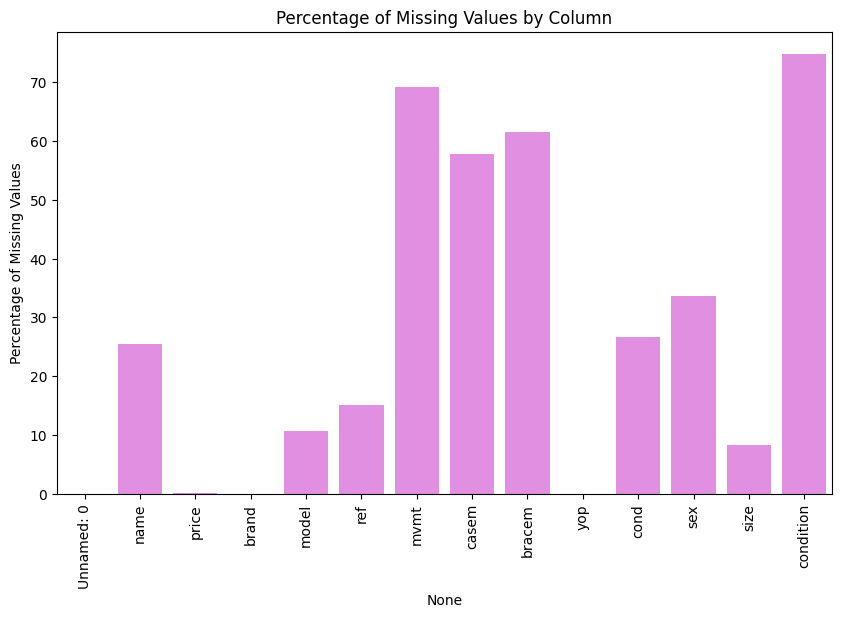

In [ ]:
#To Visualize the percentage of missing values by column we can use a bar plot:
#We use seaborn for the bar plot and matplotlib for the figure size and labels
#The index of the missing_values series contains the column names (e.g. brand, model, etc.) and the values of the missing_values series contains the percentage of missing values for each column. T
#xticks refers to the x-axis labels and rotation=90 means that we rotate the labels by 90 degrees to make them more readable

plt.figure(figsize=(10,6))
sns.barplot(x=missing_values.index, y=missing_values.values, color='violet')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Missing Values')
plt.title('Percentage of Missing Values by Column')
plt.show()

First, since `Unnamed: 0` is just an index column, we will drop it from the dataset.

In [ ]:
#Drop the Unnamed:0 column
watch_data = watch_data.drop(columns=['Unnamed: 0'])

Since `name` is just a combination of the brand and the model of the watch, we will also drop this column because it does not provide additional information for our analysis.

In [ ]:
#Drop the name column 
watch_data = watch_data.drop(columns=['name'])

Next, the reference number contains many missing values and is not used in our current version of the estimator, so we will also drop this column from the dataset.
 

In [ ]:
#Drop the reference column: 
watch_data = watch_data.drop(columns=['ref'])

Furthermore, we can see that we have two condition columns in the dataset: `cond` and `condition`. In the original head, `cond` contained information, while `condition` contained only missing values. The `cond` column also has fewer missing values, so we are tempted to delete the `condition` column. First, however, we want to check that we don't lose any information.

In [ ]:
# Look for rows where 'cond' is NaN AND 'condition' is NOT NaN
risk_rows = watch_data[watch_data['cond'].isna() & watch_data['condition'].notna()]

print(f"Number of rows at risk of losing data: {len(risk_rows)}")
display(risk_rows[['cond', 'condition']].head())

Number of rows at risk of losing data: 71569


,cond,condition
151509,NaN,Very good
151510,NaN,Very good
151511,NaN,Very good
151512,NaN,Unworn
151513,NaN,Unworn


As you can see, we would actually lose over 70,000 rows of information if we deleted this column, because it has information when the `cond` column does not. Next, we want to check if there are overlapping rows where both columns have information but the values are not the same.

In [ ]:
# Look for rows where both have data, but the values don't match
conflict_rows = watch_data[watch_data['cond'].notna() & watch_data['condition'].notna() & (watch_data['cond'] != watch_data['condition'])]

print(f"Number of conflicting rows: {len(conflict_rows)}")

Number of conflicting rows: 0


As it turns out, there are no conflicting values. This means we can use data from either the `cond` or the `condition` column. We add the `condition` column to the `cond` column where `condition` has information and `cond` does not.

In [ ]:
# Fill the NaNs in 'cond' with the values from 'condition'
watch_data['cond'] = watch_data['cond'].fillna(watch_data['condition'])


Now that we don't lose any information, we can delete the `condition` column.

In [ ]:
# now it is safe to drop the 'condition' column
watch_data = watch_data.drop(columns=['condition'])

In [ ]:
#Show the percentages of missing values by column in the dataset
missing_values = watch_data.isna().mean() * 100
missing_values

price      0.142711
brand      0.046047
model     10.708950
mvmt      69.135755
casem     57.742073
bracem    61.476813
yop        0.047102
cond       1.552949
sex       33.675934
size       8.294463
dtype: float64

We now only have missing values in 1.5% of the condition rows.

We can see that all variables are stored as the general `object` type. We want to convert them to more specific data types, such as integers, floats, and strings. This is tricky because some numbers contain extra characters like `mm` and `$`.



In [ ]:
#For the numeric columns we have to be more precise for instance look at size column unique values with pd.unique first: 
(watch_data['price']).unique()

<ArrowStringArray>
[ '$43,500',  '$71,500',  '$79,191', '$108,000',  '$27,500',  '$41,000',
  '$37,800',  '$32,182',  '$36,473',  '$35,000',
 ...
   '$3,678',  '$14,812',  '$26,208',  '$27,165', '$113,316',  '$87,192',
  '$58,464',  '$18,245',  '$20,068',  '$32,108']
Length: 36831, dtype: str

In [ ]:
pd.unique(watch_data['size'])

<ArrowStringArray>
[           '42 mm',            '39 mm',            '41 mm',
            '38 mm',       '42 x 54 mm',            '44 mm',
            '37 mm',                nan,     '34 x 9.80 mm',
    '44 x 14.45 mm',
 ...
     '42 x 9.45 mm',       '31 x 46 mm',    '42 x 12.75 mm',
 '37.50 x 43.88 mm',     '48 x 15.8 mm',     '36.5 x 51 mm',
    '41 x 10.75 mm',    '40 x 10.75 mm',       '46 x 17 mm',
     '48 x 57.5 mm']
Length: 6700, dtype: str

To solve this we will clean the data in the next step


## Part 3: Data Cleaning (Data Types)

**Data types of the variables in the dataset:**

In [ ]:
# Overview of the data types of the variables in the dataset before cleaning:
watch_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284491 entries, 0 to 284490
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   price   284085 non-null  str  
 1   brand   284360 non-null  str  
 2   model   254025 non-null  str  
 3   mvmt    87806 non-null   str  
 4   casem   120220 non-null  str  
 5   bracem  109595 non-null  str  
 6   yop     284357 non-null  str  
 7   cond    280073 non-null  str  
 8   sex     188686 non-null  str  
 9   size    260894 non-null  str  
dtypes: str(10)
memory usage: 40.5 MB


With pandas' `info()` function, we can get an overview of the data types in the dataset. Note that `object` is the general data type for string variables in pandas. For numeric columns like price, size, and year of production, we will convert them to numeric data types such as integers or floats. But let's first inspect the unique values of these features to see if there are any issues.

In [ ]:
#Unique values of the size column:
watch_data['size'].unique()


<ArrowStringArray>
[           '42 mm',            '39 mm',            '41 mm',
            '38 mm',       '42 x 54 mm',            '44 mm',
            '37 mm',                nan,     '34 x 9.80 mm',
    '44 x 14.45 mm',
 ...
     '42 x 9.45 mm',       '31 x 46 mm',    '42 x 12.75 mm',
 '37.50 x 43.88 mm',     '48 x 15.8 mm',     '36.5 x 51 mm',
    '41 x 10.75 mm',    '40 x 10.75 mm',       '46 x 17 mm',
     '48 x 57.5 mm']
Length: 6700, dtype: str

We have an issue here because sometimes the size is one number and sometimes it contains two dimensions, so we cannot just keep the first two characters and convert them. To solve this, we extract the numbers and choose the most reasonable case size. Since the majority of sizes are between 30 and 50 mm, we prefer a number above 20 and below 60. We only store one integer in millimeters for each observation because most entries only have one size value.

In [ ]:
# Initialize a function to convert raw watch size strings into one plausible case diameter in millimeters
def clean_size(value):

    # Handle real missing values such as np.nan or pd.NA
    if pd.isna(value):
        return None

    # Convert the input to a lowercase string and remove leading/trailing spaces
    text = str(value).lower().strip()

    # Handle string-based missing values
    if text in ["", "nan", "none", "<na>", "unknown"]:
        return None

    # Replace comma decimals with dot decimals, e.g. "35,5 mm" -> "35.5 mm"
    text = text.replace(",", ".")

    # Extract all integer or decimal numbers from the string
    numbers = re.findall(r"\d+(?:\.\d+)?", text)

    # If no numeric value is found, return missing
    if len(numbers) == 0:
        return None

    # Convert extracted numbers from strings to floats
    numbers = [float(num) for num in numbers]

    # Keep only plausible watch case sizes
    plausible_sizes = [num for num in numbers if 20 <= num <= 60]

    # If no plausible case size remains, return missing
    if len(plausible_sizes) == 0:
        return None

    # In multi-dimension strings, the first plausible number is usually the case diameter
    selected_size = plausible_sizes[0]


    # Round to the nearest integer and return it
    return int(round(selected_size))

# Apply the cleaning function to the size column
watch_data["size"] = watch_data["size"].apply(clean_size).astype("Int64")

# Count how many rows have no usable size after cleaning
missing_size_rows = watch_data["size"].isna().sum()

# Print a short cleaning summary
print(f"Total rows with no size value after cleaning: {missing_size_rows}")

# Show the most common cleaned sizes
display(watch_data["size"].value_counts(dropna=False).head(15))

# Show the rarest cleaned sizes to detect potential outliers
display(watch_data["size"].value_counts(dropna=False).tail(5))

Total rows with no size value after cleaning: 24740


size
40      41536
41      31613
42      30700
<NA>    24740
36      23114
44      18181
39      12809
38      10942
34      10191
43      10153
45       7999
35       6857
26       6334
37       5705
31       5616
Name: count, dtype: Int64

size
60    44
56    33
57    23
58    20
59    14
Name: count, dtype: Int64

These sizes now seem reasonable. We will not drop NAs until the end when we do another step to minimize dropping rows.

In [ ]:
# Show the top 15 most common and 5 least common entries in the raw 'yop' column 
display(watch_data['yop'].value_counts(dropna=False).head(15))
display(watch_data['yop'].value_counts(dropna=False).tail(5))


yop
Unknown                 95957
2023                    49227
2022                    20654
2021                    10501
2023 (Approximation)     6136
2020                     5573
2019                     4501
2022 (Approximation)     4132
2018                     3781
2017                     2877
2016                     2609
2015                     2235
1970 (Approximation)     2112
2014                     1927
2010                     1915
Name: count, dtype: int64

yop
1989, 1990, 1992, 1993, 1995    1
1995, 1996, 1997, 1998          1
1800                            1
2006, 2007, 2016, 2017, 2018    1
1650 (Approximation)            1
Name: count, dtype: int64

The same logic applies to the year of production. We are interested in the first four numeric year characters of the string. Therefore, we slice the year of production column to keep only the first four characters and then convert it to an integer. We remove `(Approximation)` and unknown values.

In [ ]:
# Store the amount of "Unknown" in a variable for later comparison
unknown_count = (watch_data['yop'] == 'Unknown').sum()
unknown_count

np.int64(95957)

In [ ]:
# Store the amount of "Unknown" in a variable for later comparison
unknown_count = (watch_data['yop'] == 'Unknown').sum()

# Extract the first 4 characters, coerce to numeric, and enforce plausible year range
yop_numeric = (
    watch_data['yop']
    .astype(str)
    .str.strip()
    .str[:4]
    .pipe(pd.to_numeric, errors='coerce')
)

# Set years outside the plausible range to NaN
current_year = datetime.date.today().year
yop_numeric = yop_numeric.where(
    yop_numeric.between(1500, current_year), other=pd.NA
)

# Store as nullable integer
watch_data['yop'] = yop_numeric.astype('Int64')

# Count missing values after cleaning
NA_Rows = watch_data['yop'].isna().sum()

print(f"Total rows with no yop value after cleaning: {NA_Rows}, of which {unknown_count} were already unknown")

display(watch_data['yop'].value_counts(dropna=False).head(15))
display(watch_data['yop'].value_counts(dropna=False).tail(5))

Total rows with no yop value after cleaning: 96091, of which 95957 were already unknown


yop
<NA>    96091
2023    55363
2022    24797
2021    12435
2020     6950
2019     5615
2018     4717
2017     3574
2000     3295
2016     3211
1970     3194
2015     2922
2010     2881
1990     2736
2014     2295
Name: count, dtype: Int64

yop
1871    1
1882    1
1872    1
1800    1
1650    1
Name: count, dtype: Int64

Next we will look at the unique values of the price column to see if there are any issues with the datatypes in this column as well.

In [ ]:
# Show the top 10 most common and 3 least common entries in the raw 'price' column 
display(watch_data['price'].value_counts(dropna=False).head(10))
display(watch_data['price'].value_counts(dropna=False).tail(3))

price
Price on request    14259
NaN                   406
$6,500                255
$12,500               251
$4,500                240
$4,026                239
$8,500                232
$5,500                227
$5,176                221
$7,500                219
Name: count, dtype: int64

price
$58,464    1
$18,245    1
$20,068    1
Name: count, dtype: int64

In [ ]:
# Count "Price on request" entries before cleaning
price_on_request_count = (watch_data['price'] == 'Price on request').sum()

# Remove dollar signs and commas, coerce to numeric (invalid strings become NaN)
price_numeric = (
    watch_data['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')
)

# Set zero or negative prices to NaN
price_numeric = price_numeric.where(price_numeric > 0, other=pd.NA)

# Store as nullable float
watch_data['price'] = price_numeric.astype('Float64')

# Count missing values after cleaning
NA_Rows = watch_data['price'].isna().sum()

print(f"Total rows with no price value after cleaning: {NA_Rows}, of which {price_on_request_count} were 'Price on request'")

display(watch_data['price'].value_counts(dropna=False).head(15))
display(watch_data['price'].value_counts(dropna=False).tail(5))

Total rows with no price value after cleaning: 14665, of which 14259 were 'Price on request'


price
<NA>       14665
6500.0       255
12500.0      251
4500.0       240
4026.0       239
8500.0       232
5500.0       227
5176.0       221
7500.0       219
3500.0       215
11850.0      214
3450.0       213
5750.0       211
9500.0       207
11500.0      204
Name: count, dtype: Int64

price
113316.0    1
87192.0     1
58464.0     1
18245.0     1
20068.0     1
Name: count, dtype: Int64

In [ ]:
watch_data.dtypes

price     Float64
brand         str
model         str
mvmt          str
casem         str
bracem        str
yop         Int64
cond          str
sex           str
size        Int64
dtype: object

In [25]:
summary_rows = []

for col in watch_data.columns:
    # Get the full value counts, including NaNs
    counts = watch_data[col].value_counts(dropna=False)
    
    # Extract top 5 and bottom 3
    top_5 = counts.head(5)
    bottom_3 = counts.tail(3)
    
    # Format them into readable strings like "Value (Count), Value (Count)"
    top_str = ", ".join([f"{val} ({count})" for val, count in top_5.items()])
    bottom_str = ", ".join([f"{val} ({count})" for val, count in bottom_3.items()])
    
    # Append to our summary list
    summary_rows.append({
        'Column Name': col,
        'Total Unique': len(counts),
        'Top 5 (Counts)': top_str,
        'Bottom 3 (Counts)': bottom_str
    })

# Convert the list to a DataFrame
summary_df = pd.DataFrame(summary_rows)

# Optional: This pandas setting ensures the long text wraps nicely in a notebook
# rather than truncating with "..."
with pd.option_context('display.max_colwidth', None):
    display(summary_df)

,Column Name,Total Unique,Top 5 (Counts),Bottom 3 (Counts)
0,price,36830,"<NA> (14665), 6500.0 (255), 12500.0 (251), 4500.0 (240), 4026.0 (239)","58464.0 (1), 18245.0 (1), 20068.0 (1)"
1,brand,29,"Rolex (72484), Omega (39631), Seiko (19297), Breitling (18066), Cartier (16607)","Meistersinger (1), Rado (1), Ebel (1)"
2,model,949,"nan (30466), Datejust 36 (9473), Daytona (7406), Datejust 41 (6361), Submariner Date (5296)","HyperChrome (1), Wave (1), Tourbograph (1)"
3,mvmt,4,"nan (196685), Automatic (65600), Quartz (14615), Manual winding (7591)","Automatic (65600), Quartz (14615), Manual winding (7591)"
4,casem,18,"nan (164271), Steel (75793), Gold/Steel (11031), Rose gold (9320), Yellow gold (7875)","Tantalum (23), Palladium (14), Tungsten (3)"
5,bracem,24,"nan (174896), Steel (49605), Leather (15657), Rubber (11271), Gold/Steel (10030)","Silver (13), Aluminium (9), Shark skin (9)"
6,yop,170,"<NA> (96091), 2023 (55363), 2022 (24797), 2021 (12435), 2020 (6950)","1872 (1), 1800 (1), 1650 (1)"
7,cond,8,"Very good (107740), New (77337), Unworn (50302), Good (35682), Fair (8774)","nan (4418), Poor (193), Incomplete (45)"
8,sex,3,"Men's watch/Unisex (158841), nan (95805), Women's watch (29845)","Men's watch/Unisex (158841), nan (95805), Women's watch (29845)"
9,size,42,"40 (41536), 41 (31613), 42 (30700), <NA> (24740), 36 (23114)","57 (23), 58 (20), 59 (14)"


This check over all columns shows intact values. The cleaned values look as expected, with no extra text such as "approximation" left behind.

In [ ]:
# Print NAs per column, then print the total number of rows containing at least one NA
print("--- NAs Per Column ---")
print(watch_data.isna().sum())
print(f"\nTotal rows with at least one NA: {watch_data.isna().any(axis=1).sum()}")
NA_rows_before = watch_data.isna().any(axis=1).sum()
print(f"Total rows: {NA_rows_before}")

--- NAs Per Column ---
price      14665
brand        131
model      30466
mvmt      196685
casem     164271
bracem    174896
yop        96091
cond        4418
sex        95805
size       24740
dtype: int64

Total rows with at least one NA: 249315
Total rows: 249315


We need to drop all rows where price is missing because price is our target variable and cannot be missing.It is important to acknowledge that these cleaning steps introduce a selection bias into our dataset. By dropping all rows where price is missing or listed as 'Price on request', we systematically exclude a specific segment of the market — namely rare, highly collectible, or illiquid watches whose sellers deliberately withhold the price. Similarly, dropping rows with implausible or missing year of production and size values further skews the dataset towards well-documented, mainstream luxury watches. As a result, our model is trained on a cleaner but narrower slice of the market, and its predictions will be most reliable for liquid, mid-range watches. It should not be expected to generalize well to rare vintage pieces or ultra-high-end collectibles.

In [27]:
#The dropna function is used to drop rows with missing values in the specified columns (specified by argument subset).
watch_data = watch_data.dropna(subset=['price'])

In [ ]:
#Check missing values again:
watch_data.isna().mean() * 100 

price      0.000000
brand      0.000000
model     10.884792
mvmt      69.027077
casem     57.795765
bracem    61.654548
yop       33.718026
cond       1.384225
sex       33.416720
size       8.512893
dtype: float64

In [ ]:
# Finally, let's rename our variables to make them more intuitive and easier to work with:
#We can use the rename method from pandas for this 
watch_data_cleaned = watch_data.rename(columns={'mvmt': 'movement', 'bracem': 'bracelet_material', 'casem': 'case_material', 'cond': 'condition'})

In [ ]:
watch_data_cleaned

,price,brand,model,movement,case_material,bracelet_material,yop,condition,sex,size
0,43500.0,Audemars Piguet,Royal Oak Offshore Chronograph,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42
1,71500.0,Audemars Piguet,Royal Oak Selfwinding,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39
2,79191.0,Audemars Piguet,Royal Oak Chronograph,Automatic,Steel,Steel,<NA>,Unworn,NaN,41
3,108000.0,Audemars Piguet,Royal Oak Chronograph,Automatic,Steel,Steel,2022,New,Men's watch/Unisex,38
4,27500.0,Audemars Piguet,Royal Oak Offshore Chronograph,Automatic,Steel,Steel,<NA>,Very good,Men's watch/Unisex,42
...,...,...,...,...,...,...,...,...,...,...
284486,9790.0,Zenith,Defy El Primero,NaN,NaN,NaN,2022,Very good,Men's watch/Unisex,44
284487,8450.0,Zenith,Chronomaster Sport,NaN,NaN,NaN,2021,Very good,Men's watch/Unisex,41
284488,16500.0,Zenith,El Primero,NaN,NaN,NaN,2019,Very good,Men's watch/Unisex,38
284489,9000.0,Zenith,Chronomaster Sport,NaN,NaN,NaN,2021,Unworn,Men's watch/Unisex,41


## Part 4: Exploratory Data Analysis (EDA)

### 4.1. Price Variable

In this section, we want to understand our dataset better and get insights into the distribution and relationships of variables. This helps us understand whether we need transformations or whether outliers might affect our model. First, we will look at the distribution of the price variable because this is our main target variable.

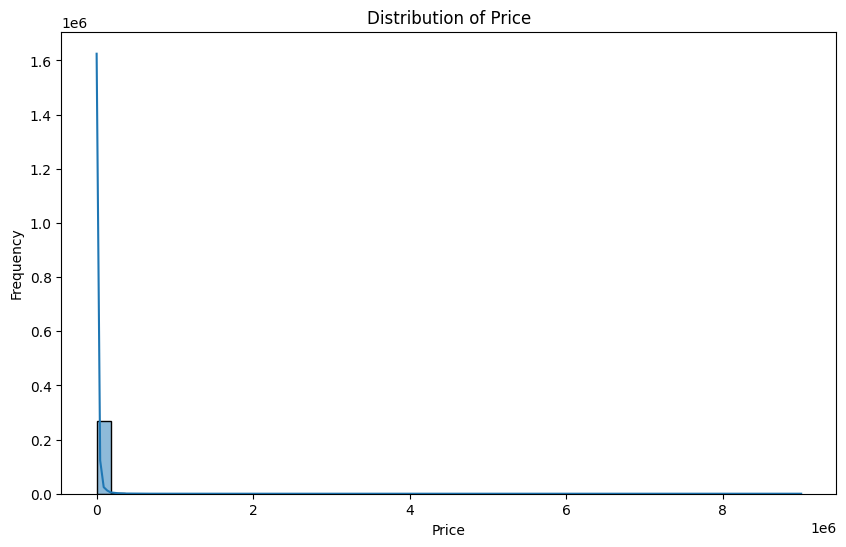

In [ ]:
#To plot the distribution of the price variable we use the seaborn library and the histplot function to plot a histogram of the  price variable.
plt.figure(figsize=(10,6))
sns.histplot(watch_data_cleaned['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price') 
plt.ylabel('Frequency')
plt.show()

We can see that the distribution of the price variable is highly right-skewed because of very expensive outliers and is not normally distributed. A log transformation could potentially bring the distribution closer to a normal distribution. Let's try this out:

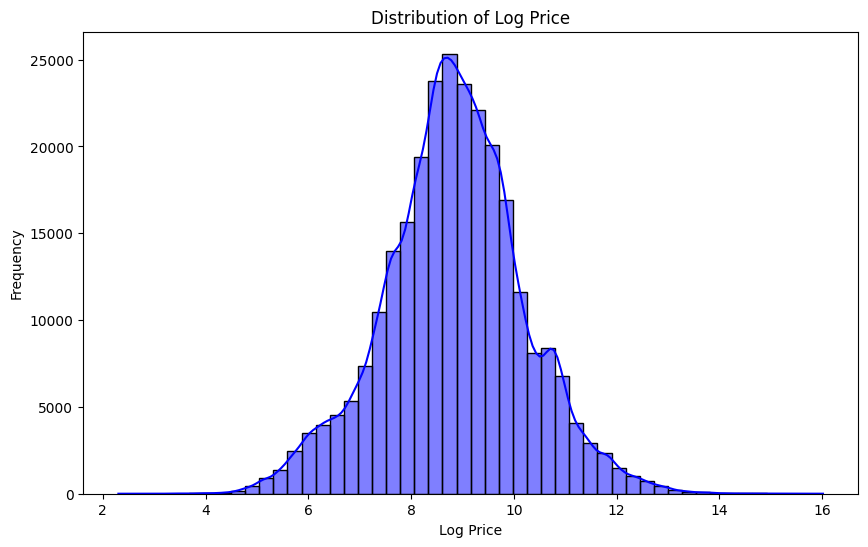

In [ ]:
#Distribution of the log price variable:
#np.log is a numpy function that applies the natural logarithm to the values in the price column. 

plt.figure(figsize=(10,6))
sns.histplot(np.log(watch_data_cleaned['price']), bins=50, kde=True, color='blue')
plt.title('Distribution of Log Price')
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.show()

We can see that the log price is closer to a normal distribution than the original price variable. Therefore, we will use the log price as our target variable for the prediction task in this project.

Furthermore, we are interested in the price ranges of our dataset. For this, we will group the dataset into three price range categories: low, medium, and high. Then we will use a bar plot to see how many observations we have in each category.



In [33]:
# Create a separate copy of the cleaned dataset for EDA visualizations.
# This avoids changing the main dataset that will later be used for preprocessing and modeling.
eda_data = watch_data_cleaned.copy()

# Add a log-transformed price column for visualizations.
# Watch prices are highly skewed, so log_price makes boxplots easier to interpret.
eda_data["log_price"] = np.log(eda_data["price"])

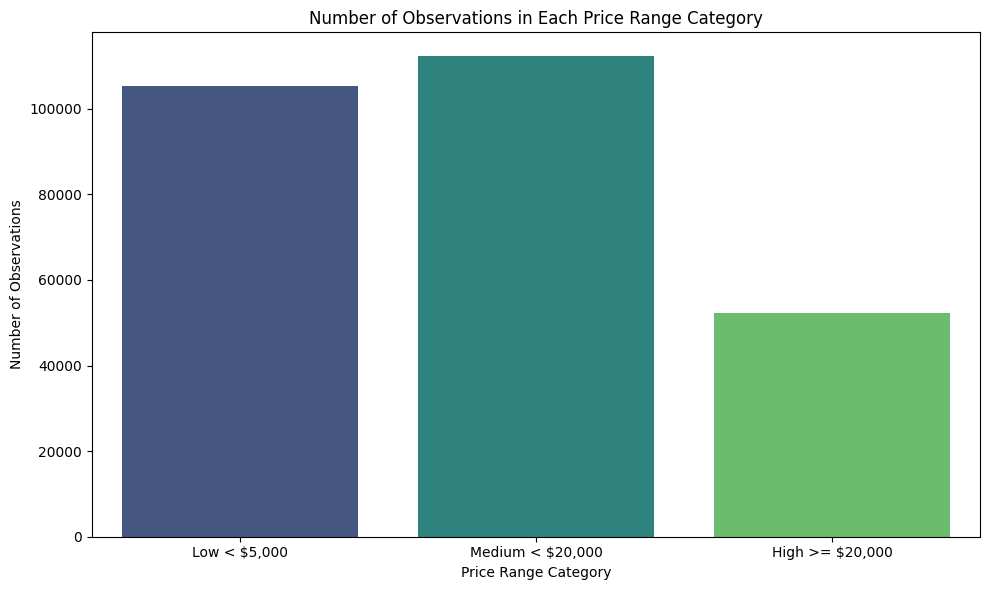

In [34]:
# Define three price categories using boolean masks.
# Low: price below $5,000
# Medium: price between $5,000 and $20,000
# High: price at or above $20,000

category_low = watch_data_cleaned[watch_data_cleaned["price"] < 5000]

category_medium = watch_data_cleaned[
    (watch_data_cleaned["price"] < 20000) &
    (watch_data_cleaned["price"] >= 5000)
]

category_high = watch_data_cleaned[watch_data_cleaned["price"] >= 20000]

# Create category labels and corresponding observation counts.
categories = ["Low < $5,000", "Medium < $20,000", "High >= $20,000"]
counts = [len(category_low), len(category_medium), len(category_high)]

# Plot the number of observations per price range category.
# The hue argument avoids the Seaborn FutureWarning when using a palette.
plt.figure(figsize=(10, 6))
sns.barplot(
    x=categories,
    y=counts,
    hue=categories,
    palette="viridis",
    legend=False
)

plt.title("Number of Observations in Each Price Range Category")
plt.xlabel("Price Range Category")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

We can see that most of our dataset is concentrated in the medium category. There is also a significant number of observations in the low category and a smaller amount of observations in the high category. This is important to know for our prediction task since it means that our model will have more data to learn from in the low/medium price range than in the high price range. 

### 4.2. Brand Variable

Next up, we are interested in the distribution of the brand variable in our dataset. For this we will look at a bar plot to see how many observations we have for each brand in the dataset.

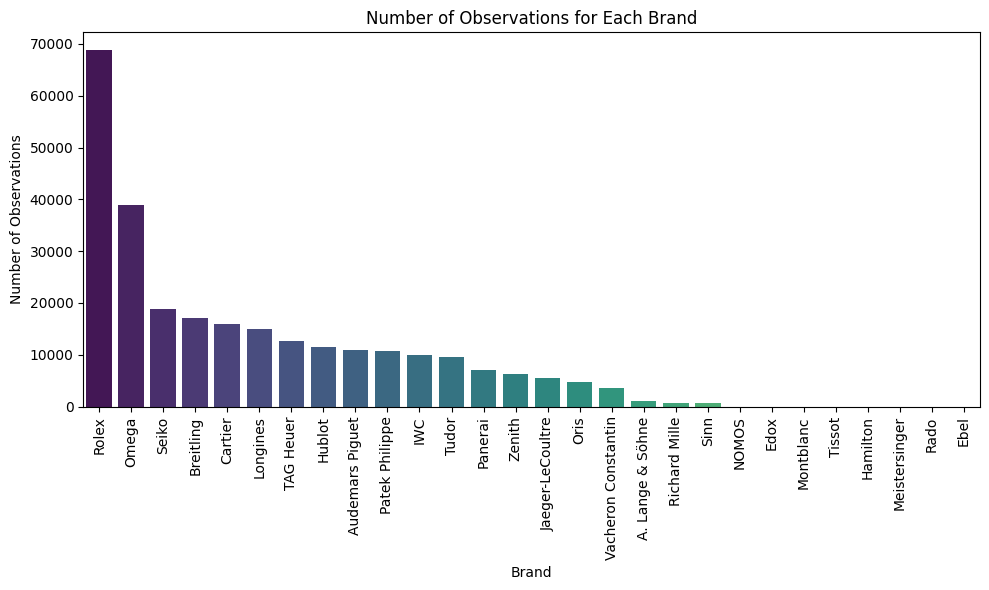

In [35]:
# Count how often each brand appears in the cleaned dataset.
unique_brands = watch_data_cleaned["brand"].value_counts()

# Plot the number of observations per brand.
# The hue argument avoids the Seaborn FutureWarning when using a palette.
plt.figure(figsize=(10, 6))
sns.barplot(
    x=unique_brands.index,
    y=unique_brands.values,
    hue=unique_brands.index,
    palette="viridis",
    legend=False
)

plt.title("Number of Observations for Each Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Observations")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Most of our dataset is concentrated on the Rolex brand, but Omega and Seiko have also a significant amount of observations in the dataset. 

### 4.3. Model Variable

Next we will look at the the most common watch models in our dataset. For this we will look again at the value counts of the model variable.

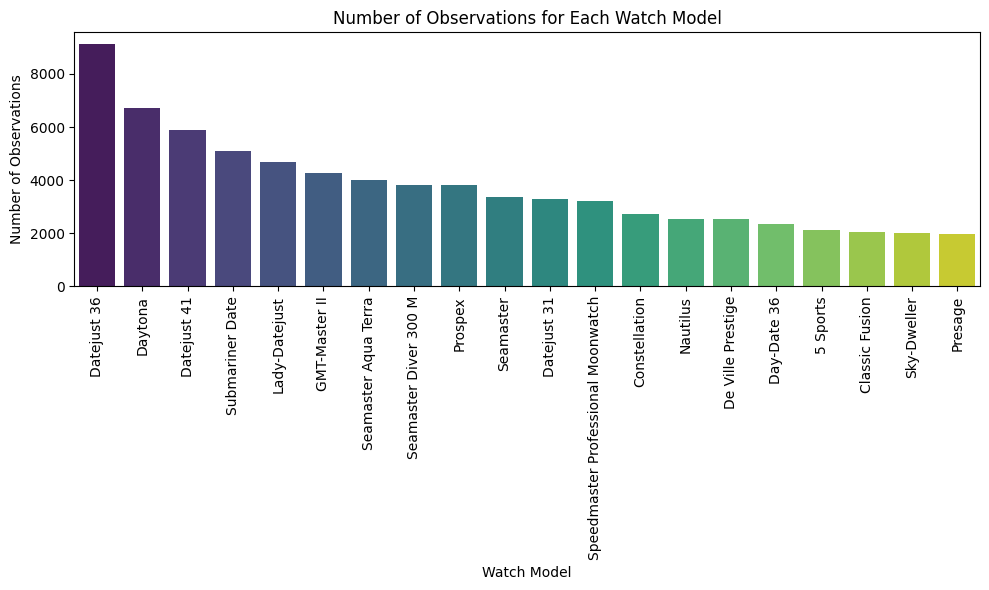

In [36]:
# First, we again apply the previously described value_counts method.
# Since value_counts sorts in descending order with .head(20), we can get the 20 most common watch models in our dataset.
models = eda_data["model"].value_counts().head(20)

# Convert the sorted value_counts output into a DataFrame.
# This keeps the sorted model names and their corresponding counts aligned.
models_df = models.reset_index()
models_df.columns = ["model", "count"]

# We again plot the most common watch models.
# Seaborn barplot is used for the barplot.
plt.figure(figsize=(10, 6))
sns.barplot(
    data=models_df,
    x="model",
    y="count",
    hue="model",
    palette="viridis",
    legend=False
)

plt.title("Number of Observations for Each Watch Model")
plt.xlabel("Watch Model")
plt.xticks(rotation=90)
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

The most common models stem from the Datejust and Daytona of the Rolex brand. Which is not surprising since we have the most observations from the Rolex brand in our dataset.

### 4.4. Correlation between Variables 

**Size vs log(price)**

In this section we are interested in the relationship between different variables in our dataset. For visualizing the relationship between the different variables we will be using scatter plots for numeric variables.

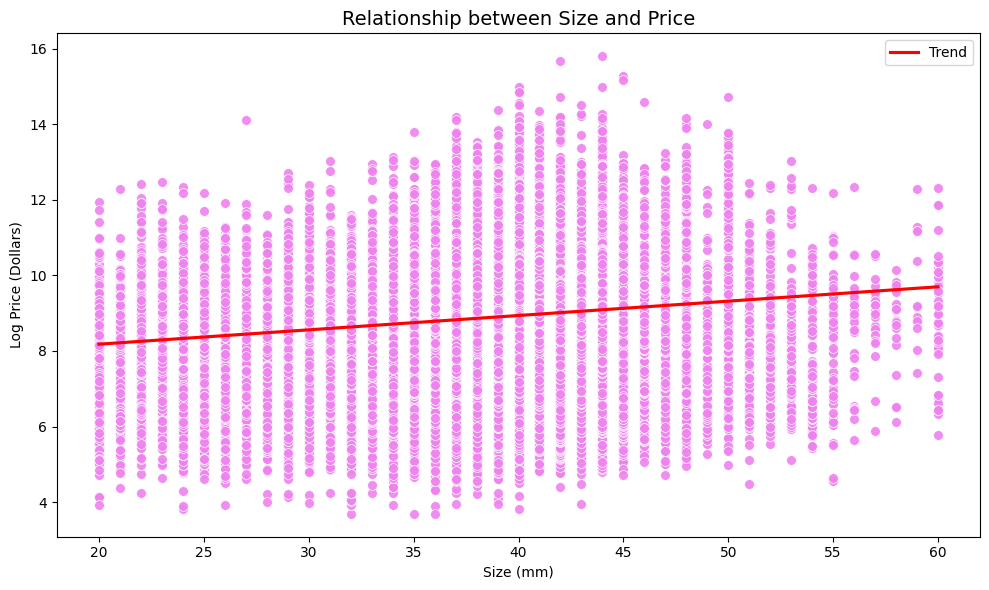

In [37]:
# Plot the relationship between log price and size with a scatter plot.

plt.figure(figsize=(10, 6))

# Scatterplot of size and log price:
# The x-axis is the size variable and the y-axis is the precomputed log_price variable from eda_data.
sns.scatterplot(
    data=eda_data,
    x="size",
    y="log_price",
    color="violet",
    alpha=0.9,
    s=50
)

# Regression line with seaborn regplot function.
sns.regplot(
    data=eda_data,
    x="size",
    y="log_price",
    scatter=False,
    color="red",
    label="Trend"
)

plt.title("Relationship between Size and Price", fontsize=14)
plt.xlabel("Size (mm)")
plt.ylabel("Log Price (Dollars)")
plt.legend()
plt.tight_layout()
plt.show()

 Larger watch sizes tend to command higher prices, as shown by the positive trend line. However, the wide spread of points indicates that size alone is a weak predictor of price, suggesting other factors like brand and material play a more significant role. For modeling, this implies that size should not be used as a standalone feature but rather in combination with other variables to improve predictive power (as done in our project)

**Year of production vs log(price)**

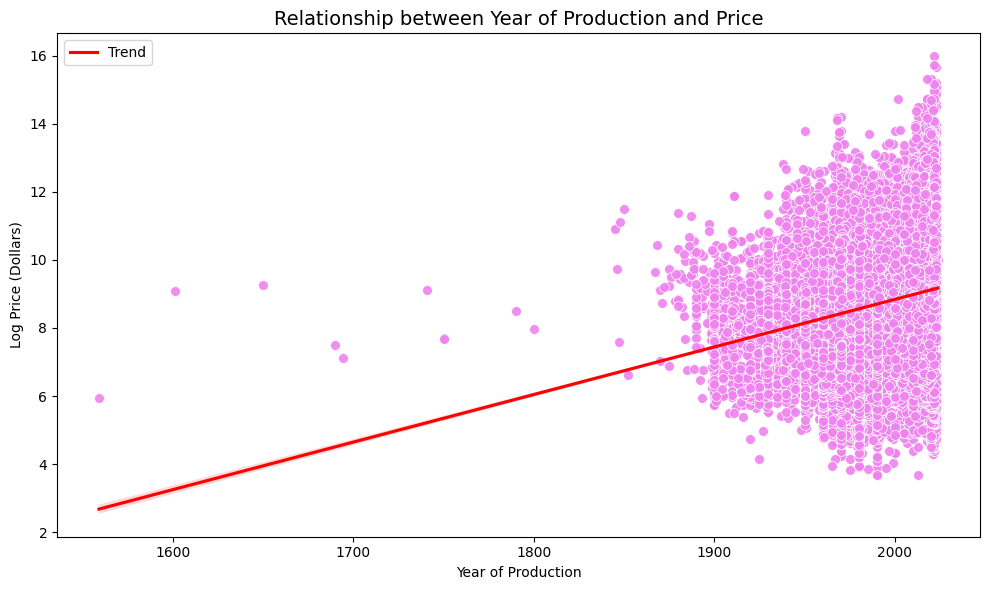

In [38]:
# Plot the relationship between log price and year of production with a scatter plot.

plt.figure(figsize=(10, 6))

# Scatterplot of yop and log price:
# The x-axis is the yop variable and the y-axis is the precomputed log_price variable from eda_data.
sns.scatterplot(
    data=eda_data,
    x="yop",
    y="log_price",
    color="violet",
    alpha=0.9,
    s=50
)

# Regression line with seaborn regplot function.
sns.regplot(
    data=eda_data,
    x="yop",
    y="log_price",
    scatter=False,
    color="red",
    label="Trend"
)

plt.title("Relationship between Year of Production and Price", fontsize=14)
plt.xlabel("Year of Production")
plt.ylabel("Log Price (Dollars)")
plt.legend()
plt.tight_layout()
plt.show()

While more recent watches tend to fetch higher prices overall as shown by the positive trend line, the outliers before 1900 reaching log prices above regression line reveal that rare vintage and antique pieces can also command very high prices. As standalone year of production is likely a weak predictor of price 

**brand vs log(price)**

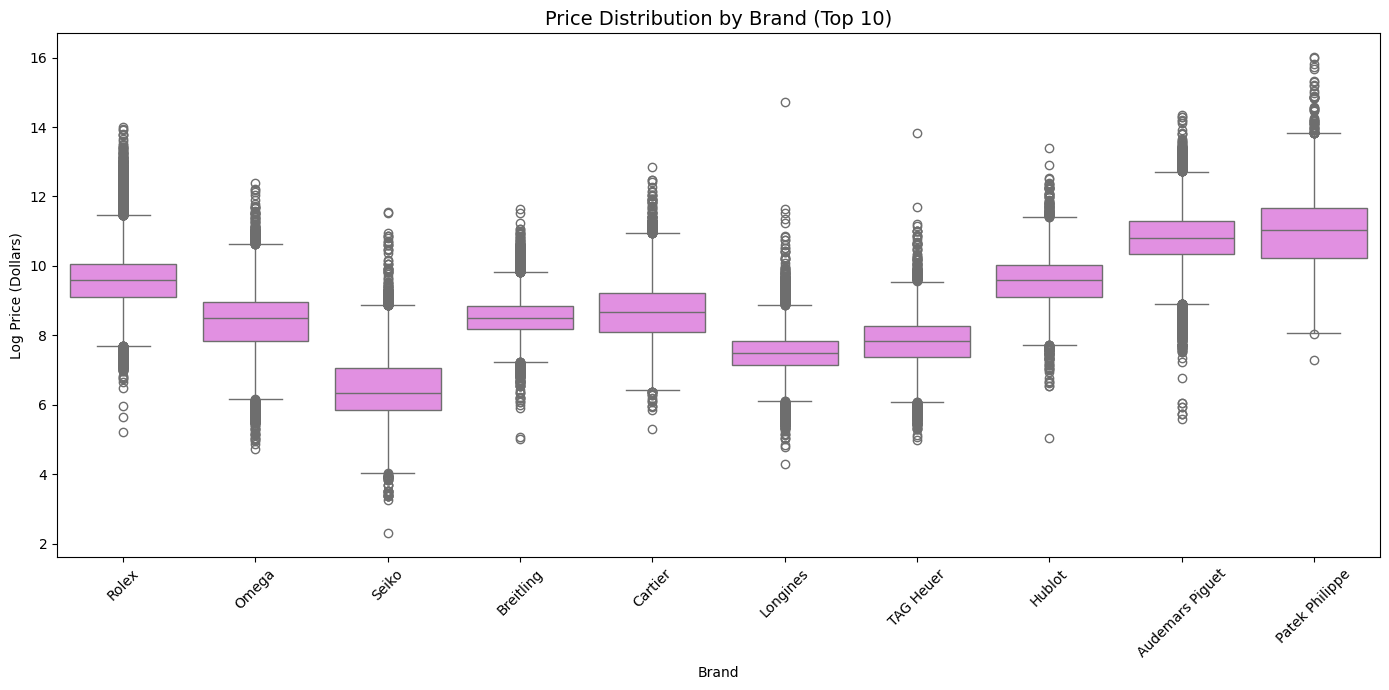

In [39]:
# We will look at the relationship between the price variable and the brand variable with a boxplot.
# First, we get the top 10 most common brands in our dataset with value_counts and head(10).
top_10_brands = eda_data["brand"].value_counts().head(10).index

# Filter eda_data for the top 10 most common brands.
brand_plot_data = eda_data[eda_data["brand"].isin(top_10_brands)].copy()

# Boxplot using seaborn boxplot function:
# isin is used to filter the dataset for the top 10 most common brands in our dataset.
# Rotate the labels on the x-axis by 45 degrees to make them more readable.
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=brand_plot_data,
    x="brand",
    y="log_price",
    order=top_10_brands,
    color="violet"
)

plt.xticks(rotation=45)
plt.title("Price Distribution by Brand (Top 10)", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Log Price (Dollars)")
plt.tight_layout()
plt.show()

Patek Philippe and Audemars Piguet clearly occupy the ultra-luxury segment with the highest median prices and wide distributions, while Seiko and Longines sit at the more accessible end of the spectrum. The large spread within most brands indicates that even within a single brand, price varies enormously depending on the model and condition, confirming that brand alone is a strong but insufficient predictor of price.

**case and bracelet material vs log(price)**

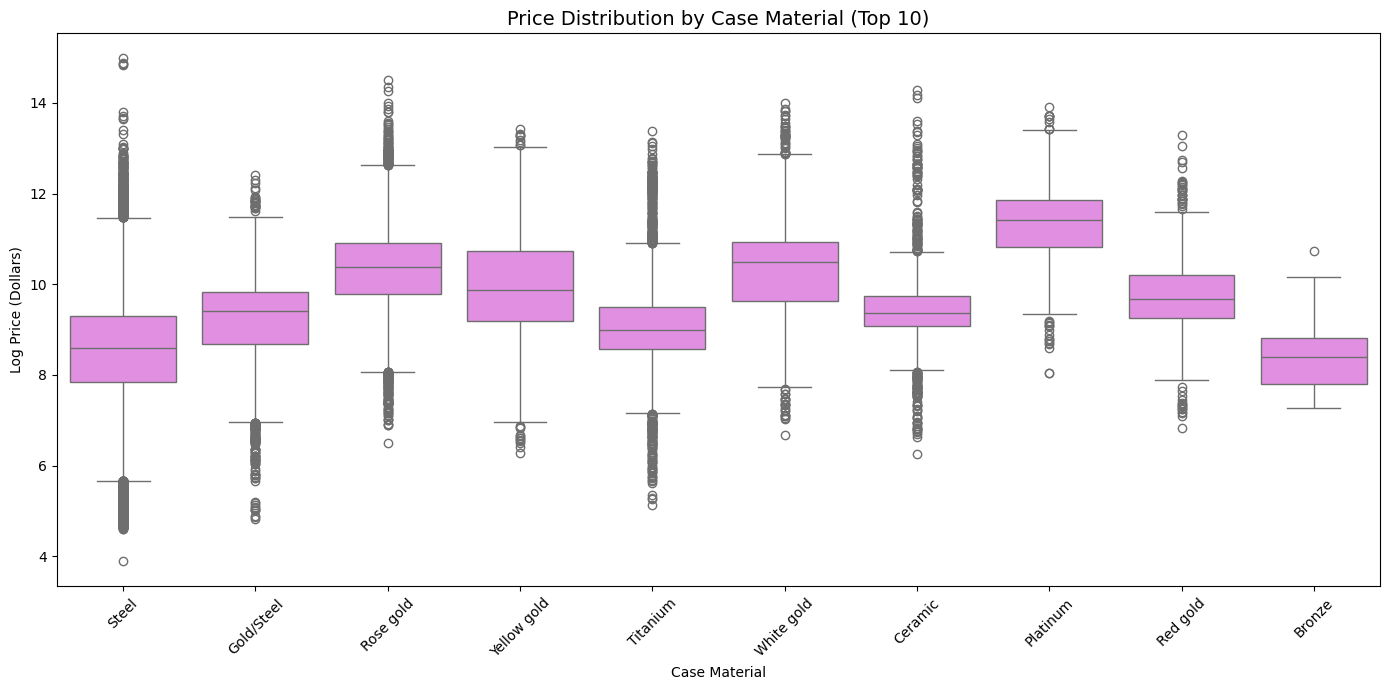

In [40]:
# We will look at the relationship between the price variable and the case_material variable with a boxplot.
# First, we get the top 10 most common case materials in our dataset with value_counts and head(10).
top_10_case_materials = eda_data["case_material"].value_counts().head(10).index

# Filter eda_data for the top 10 most common case materials.
case_material_plot_data = eda_data[
    eda_data["case_material"].isin(top_10_case_materials)
].copy()

# Boxplot using seaborn boxplot function:
# isin is used to filter the dataset for the top 10 most common case materials in our dataset.
# Rotate the labels on the x-axis by 45 degrees to make them more readable.
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=case_material_plot_data,
    x="case_material",
    y="log_price",
    order=top_10_case_materials,
    color="violet"
)

plt.xticks(rotation=45)
plt.title("Price Distribution by Case Material (Top 10)", fontsize=14)
plt.xlabel("Case Material")
plt.ylabel("Log Price (Dollars)")
plt.tight_layout()
plt.show()

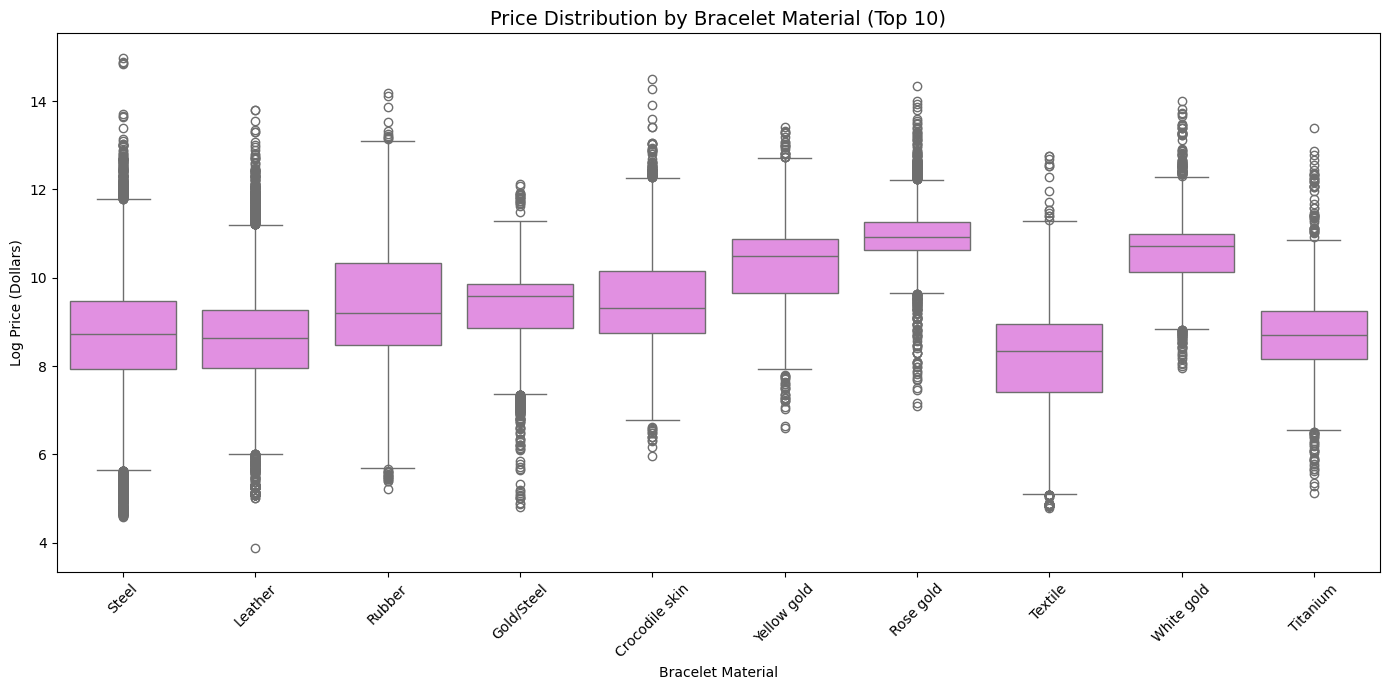

In [41]:
# We will look at the relationship between the price variable and the bracelet_material variable with a boxplot.
# First, we get the top 10 most common bracelet materials in our dataset with value_counts and head(10).
top_10_bracelet_materials = eda_data["bracelet_material"].value_counts().head(10).index

# Filter eda_data for the top 10 most common bracelet materials.
bracelet_material_plot_data = eda_data[
    eda_data["bracelet_material"].isin(top_10_bracelet_materials)
].copy()

# Boxplot using seaborn boxplot function:
# isin is used to filter the dataset for the top 10 most common bracelet materials in our dataset.
# Rotate the labels on the x-axis by 45 degrees to make them more readable.
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=bracelet_material_plot_data,
    x="bracelet_material",
    y="log_price",
    order=top_10_bracelet_materials,
    color="violet"
)

plt.xticks(rotation=45)
plt.title("Price Distribution by Bracelet Material (Top 10)", fontsize=14)
plt.xlabel("Bracelet Material")
plt.ylabel("Log Price (Dollars)")
plt.tight_layout()
plt.show()

**Case Material:** Precious metals like platinum, white gold and rose gold command significantly higher median prices than steel, which despite being the most common material spans a very wide price range. This confirms that case material is a strong price signal and will likely be a valuable feature in modeling.

**Bracelet Material:** Rose gold bracelets stand out with the highest median price, while steel and titanium sit at the lower end. Interestingly the differences between bracelet materials are less pronounced than for case materials,

**Condition vs log(price)**

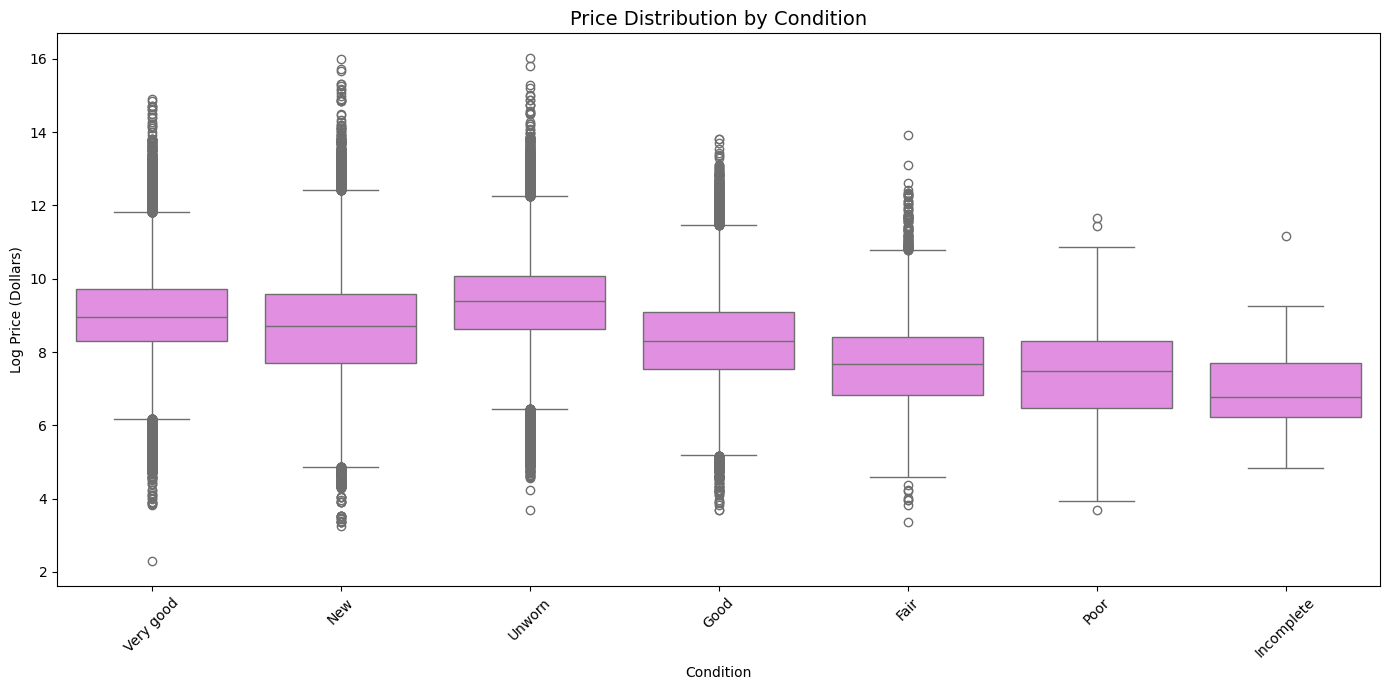

In [42]:
# Boxplot using seaborn boxplot function:
# Condition has only 7 different values in the dataset, so we do not have to filter for the top 10 most common conditions.
# Rotate the labels on the x-axis by 45 degrees to make them more readable.

condition_order = eda_data["condition"].value_counts().index

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=eda_data,
    x="condition",
    y="log_price",
    order=condition_order,
    color="violet"
)

plt.xticks(rotation=45)
plt.title("Price Distribution by Condition", fontsize=14)
plt.xlabel("Condition")
plt.ylabel("Log Price (Dollars)")
plt.tight_layout()
plt.show()

Even if new watches seem to have a similar price to "Very Good" watches, the overall trend is clear and consistent with market expectations that better condition correlates with higher prices. This suggests that condition should be included as a key feature in our model

## Part 5: Data Preprocessing

In this section we preprocess some findings that we made in the EDA section. For example, we will apply the log transformation to the price variable.

In [43]:
#Transform the price variable with a log transformation
watch_data_cleaned['log_price'] = np.log(watch_data_cleaned['price'])

#Afterwards, we can drop the normal price variable since we have the log price variable now: 
watch_data_cleaned = watch_data_cleaned.drop(columns=['price'])

Our machine learning approach can handle NA values. For numerical columns (size, yop) we leave missing values as NaN, since XGBoost handles these natively by learning optimal split directions for missing data. For categorical columns, however, missingness must be made explicit. We fill all missing categorical values with the string "Unknown", treating absence of information as a distinct, meaningful category in itself. This is methodologically justified because missingness in this dataset is unlikely to be random — a seller omitting the movement type or condition is itself a signal the model can learn from. Replacing with "Unknown" preserves this signal without introducing any imputation bias.

In [44]:
# 1. Define your categorical columns explicitly with the newly renamed variables
categorical_cols = ['brand', 'model', 'movement', 'case_material', 'bracelet_material', 'condition', 'sex']

# 2. Fill all missing values in these specific columns with the string "Unknown"
watch_data_cleaned[categorical_cols] = watch_data_cleaned[categorical_cols].fillna("Unknown")

# Note: We intentionally do NOT touch 'size', 'yop', or 'price' here. 
# They stay exactly as they are (containing standard pd.NA or np.nan).

# 3. Print a quick verification check
print("--- Missing Values Ready for XGBoost ---")
print(watch_data_cleaned.isna().sum())

--- Missing Values Ready for XGBoost ---
brand                    0
model                    0
movement                 0
case_material            0
bracelet_material        0
yop                  90980
condition                0
sex                      0
size                 22970
log_price                0
dtype: int64


Feature Encoding (for XGBoost)

Before feeding categorical data into XGBoost, we need to translate text (like "Rolex" or "Automatic") into a format the model understands—without crashing our memory or accidentally "cheating" by leaking future data. 

To get the best performance, we are using a hybrid approach:

*   The Split First Rule: We split the data into Train and Test sets before doing anything else. This is the golden rule to prevent data leakage.
*   Low Cardinality (Movement, Condition, Sex): We convert these directly to Pandas category datatypes. Modern XGBoost handles these natively, which is much more memory-efficient than generating dozens of One-Hot Encoded columns.
*   High Cardinality (Brand, Model): One-Hot Encoding thousands of unique watch models would create massive memory bloat. Instead, we use Target Encoding. This replaces the brand or model name with its average historical price from the training data. Critically, the TargetEncoder is placed inside the Pipeline, which is passed to RandomizedSearchCV. This means the encoder is refit separately within each cross-validation fold, using only that fold's training portion. The validation fold never contributes to the encoding — preventing target leakage entirely.

In [ ]:
# 1. Define the feature matrix (X) and target variable (y)
# X contains all explanatory variables used to predict the watch price.
# y contains the log-transformed price, which is the target variable for the model.
X = watch_data_cleaned.drop(columns=["log_price"]).copy()
y = watch_data_cleaned["log_price"].copy()

# 2. Split the data into training and test sets before any encoding.
# This keeps the final test set untouched until final evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 3. Define low-cardinality categorical columns.
# These variables only have a limited number of categories.
# XGBoost can handle them natively if their dtype is set to "category".
low_card_cols = ["movement", "case_material", "bracelet_material", "condition", "sex"]

# 4. Define high-cardinality categorical columns.
# These variables have many unique categories and are therefore target-encoded.
# Important: The actual target encoding will be done inside the pipeline later.
# This prevents target leakage within cross-validation.
high_card_cols = ["brand", "model"]

# 5. Convert low-cardinality columns to category dtype for XGBoost native categorical support.
# We apply the conversion to both train and test, but we do not fit anything here.
# Important: the test set is anchored to the *training* categories so that the
# integer codes XGBoost consumes are identical in both frames. Levels that only
# occur in the test split become NaN and are treated as missing.
for col in low_card_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = pd.Categorical(X_test[col], categories=X_train[col].cat.categories)

# 6. Quick verification.
# At this stage, brand and model should still be raw categories, not target-encoded numbers.
print("--- Training and Test Data Prepared ---")
display(X_train.head())
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

--- Training and Test Data Prepared ---


,brand,model,movement,case_material,bracelet_material,yop,condition,sex,size
116341,Omega,Speedmaster Professional Moonwatch,Unknown,Unknown,Unknown,2022,Very good,Men's watch/Unisex,42
261278,TAG Heuer,Carrera Calibre 5,Unknown,Unknown,Unknown,2011,Good,Men's watch/Unisex,39
83578,Longines,Heritage,Automatic,Steel,Leather,<NA>,New,Men's watch/Unisex,41
101290,Omega,De Ville Trésor,Unknown,Unknown,Unknown,2023,Unworn,Men's watch/Unisex,40
51831,Hublot,Big Bang Ferrari,Automatic,Unknown,Unknown,<NA>,Good,Men's watch/Unisex,45


X_train shape: (215860, 9)
X_test shape: (53966, 9)


## Part 6: Machine Learning

Establishing the Benchmark

Before training a complex algorithm like XGBoost, it is essential to establish a performance baseline. This baseline serves as a reality check, providing a clear point of reference to ensure the advanced model is actually learning meaningful patterns from the data rather than just guessing. 

To create this benchmark, we implemented two basic models:

*   Dummy Regressor: A naive baseline that completely ignores the watch features and simply predicts the median price of the training set for every single entry. 
*   Ridge Regressor: A standard linear model. Because linear algorithms cannot natively process missing values or raw text (unlike XGBoost), we used a temporary Scikit-Learn pipeline to impute missing numbers and One-Hot Encode the text categories strictly for this baseline.

We evaluated both models using Mean Absolute Error (MAE). Since the target variable was previously log-transformed (log_price), we exponentiated the predictions back into dollars. This provides a highly interpretable performance metric: exactly how many dollars our models' predictions are off by on average.

In [ ]:
# 1. Dummy Regressor baseline
# The DummyRegressor does not use any features.
# It simply predicts the median target value from the training data.
dummy_reg = DummyRegressor(strategy="median")
dummy_reg.fit(X_train, y_train)
dummy_preds_log = dummy_reg.predict(X_test)


# 2. Ridge Regressor baseline
# Ridge is a simple linear baseline model.
# Unlike XGBoost, Ridge cannot handle missing values or raw categorical variables directly.
# Therefore, we impute missing numerical values and one-hot encode categorical variables.

# Numerical features are used as numbers.
numeric_features = ["size", "yop"]

# Categorical features are converted into dummy variables via OneHotEncoder.
categorical_features = [
    "brand",
    "model",
    "movement",
    "case_material",
    "bracelet_material",
    "condition",
    "sex"
]

# Create a preprocessing pipeline:
# - numerical columns: replace missing values with the median
# - categorical columns: replace missing values with the most frequent value, then one-hot encode
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features)
    ]
)

# Build the Ridge pipeline.
# The preprocessing step is fitted only on the training data.
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge())
])

# Fit and predict.
ridge_pipeline.fit(X_train, y_train)
ridge_preds_log = ridge_pipeline.predict(X_test)


# 3. Evaluate using MAE in actual dollars
# Since our target is log_price, we exponentiate predictions and actual values.
y_test_dollars = np.exp(y_test)
dummy_preds_dollars = np.exp(dummy_preds_log)
ridge_preds_dollars = np.exp(ridge_preds_log)

dummy_mae = mean_absolute_error(y_test_dollars, dummy_preds_dollars)
ridge_mae = mean_absolute_error(y_test_dollars, ridge_preds_dollars)

dummy_mape = mean_absolute_percentage_error(y_test_dollars, dummy_preds_dollars) * 100
ridge_mape = mean_absolute_percentage_error(y_test_dollars, ridge_preds_dollars) * 100

print("--- Baseline Benchmarks ---")
print(f"Dummy Regressor MAE: ${dummy_mae:,.2f} | MAPE: {dummy_mape:.1f}%")
print(f"Ridge Regressor MAE: ${ridge_mae:,.2f} | MAPE: {ridge_mape:.1f}%")

--- Baseline Benchmarks ---
Dummy Regressor MAE: $15,056.18 | MAPE: 216.7%
Ridge Regressor MAE: $6,992.31 | MAPE: 40.3%


Data Splitting & Hyperparameter Tuning

**Takes 10-20 minutes to run on a standard laptop**

Machine learning algorithms contain various adjustable settings, known as hyperparameters, which control how the model learns. Default settings are rarely optimal for a specific dataset. To maximize the model's predictive accuracy, we perform hyperparameter tuning to find the most effective combination of these settings.

To execute this safely and prevent data leakage, we utilize a 5-fold Cross-Validation strategy exclusively on the 80% training set, leaving the 20% test set completely untouched. 

*   Randomized Search: Instead of an exhaustive and computationally expensive grid search, we use `RandomizedSearchCV` to test a diverse, random sample of hyperparameter combinations (such as `learning_rate`, `max_depth`, and `n_estimators`).
*   Cross-Validation (CV): The training data is split into 5 subsets. The model trains on 4 subsets and validates on the 5th, rotating through all of them. This ensures the model's performance is rigorously tested on unseen data during the tuning phase without exposing it to the final holdout test set.

In [ ]:
# 1. Initialize the XGBoost regressor.
# We use tree_method="hist" because it supports native categorical handling in XGBoost.
xgb_model = xgb.XGBRegressor(
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    objective="reg:squarederror"
)

# 2. Build a modeling pipeline.
# The TargetEncoder is placed inside the pipeline so that it is refitted separately
# within each cross-validation fold.
# This prevents CV leakage: the encoder cannot use target values from the validation fold.
xgb_pipeline = Pipeline([
    ("target_encoder", ce.TargetEncoder(
        cols=high_card_cols,
        min_samples_leaf=10,
        smoothing=10
    )),
    ("xgb", xgb_model)
])

# 3. Define the hyperparameter search space.
# Because XGBoost is now inside a pipeline step named "xgb",
# all hyperparameter names must start with "xgb__".
param_distributions = {
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2],
    "xgb__max_depth": [4, 5, 6, 7, 8, 9, 10],
    "xgb__n_estimators": [100, 300, 500, 750, 1000],
    "xgb__subsample": [0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

# 4. Configure RandomizedSearchCV.
# The full pipeline is cross-validated, not only the XGBoost model.
# This means target encoding happens correctly inside each CV fold.
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 5. Fit the randomized search on the training set only.
random_search.fit(X_train, y_train)

# 6. Store the best full pipeline.
# This object includes both the fitted TargetEncoder and the fitted XGBoost model.
best_model = random_search.best_estimator_

# 7. Generate predictions on the untouched test set.
# The pipeline target-encodes X_test automatically.
xgb_preds_log = best_model.predict(X_test)

# 8. Print tuning results.
print("--- Tuning Complete ---")
print("Best Parameters Found:")
print(random_search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
--- Tuning Complete ---
Best Parameters Found:
{'xgb__subsample': 1.0, 'xgb__n_estimators': 750, 'xgb__max_depth': 9, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.8}


In [48]:
# Use the best model found by RandomizedSearchCV.
# This is a full pipeline containing:
# 1. the fitted TargetEncoder for brand and model
# 2. the fitted XGBoost regressor
final_model = random_search.best_estimator_

# Predict on the untouched test set.
# The pipeline automatically applies the TargetEncoder before prediction.
xgb_preds_log = final_model.predict(X_test)

# Convert log-price predictions and actual log-prices back to dollar prices.
# Since the model predicts log_price, we exponentiate the values for interpretability.
y_test_dollars = np.exp(y_test)
xgb_preds_dollars = np.exp(xgb_preds_log)

# Evaluate the final XGBoost pipeline in dollar terms.
xgb_mae = mean_absolute_error(y_test_dollars, xgb_preds_dollars)
xgb_mape = mean_absolute_percentage_error(y_test_dollars, xgb_preds_dollars) * 100
xgb_rmse = np.sqrt(mean_squared_error(y_test_dollars, xgb_preds_dollars))

print("\n" + "="*30)
print("--- Final Evaluation ---")
print("="*30)
print(f"XGBoost MAE:  Off by ${xgb_mae:,.2f} on average")
print(f"XGBoost MAPE: Off by {xgb_mape:.1f}% on average")
print(f"XGBoost RMSE: ${xgb_rmse:,.2f}")



--- Final Evaluation ---
XGBoost MAE:  Off by $5,723.54 on average
XGBoost MAPE: Off by 30.3% on average
XGBoost RMSE: $33,176.88


### Visualizing Model Performance

Numbers in a console are great, but a clean visual makes the results immediately clear. In this step, we are graphing the Mean Absolute Error (MAE) of our final, fully-tuned XGBoost model against the two baselines we established back in Step 4. 

This chart acts as our ultimate reality check: it visually proves whether all the complex encoding and hyperparameter tuning we performed actually resulted in a better pricing model than a simple linear algorithm or a naive guess.

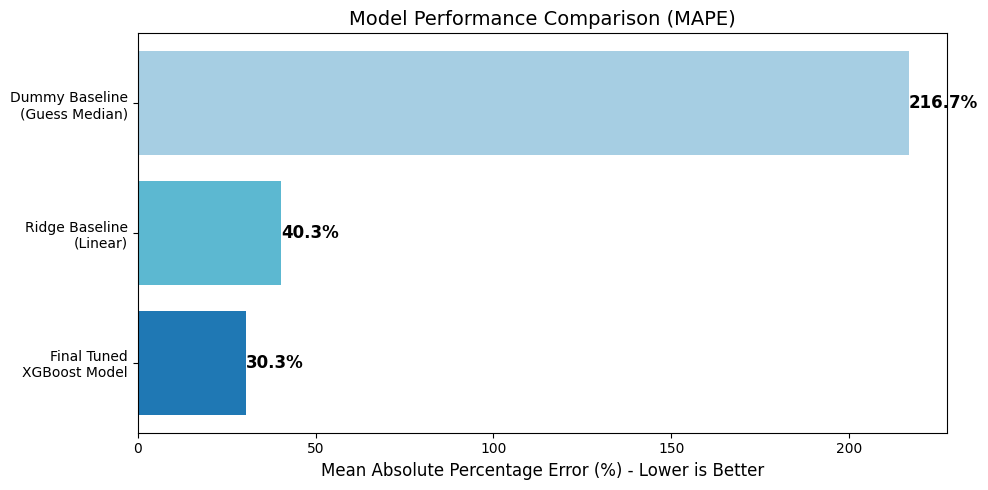

In [ ]:
# VISUALIZATION 1: Error Comparison Bar Chart

# Define the models and their respective errors (using variables from Step 4 & 6)
model_names = ['Dummy Baseline\n(Guess Median)', 'Ridge Baseline\n(Linear)', 'Final Tuned\nXGBoost Model']
errors = [dummy_mape, ridge_mape, xgb_mape]

# Colors: Light blue for baseline, medium for ridge, dark blue for our winner
colors = ['#a6cee3', '#5cb8d1', '#1f78b4']

plt.figure(figsize=(10, 5))
bars = plt.barh(model_names, errors, color=colors)

# Add formatting
plt.xlabel('Mean Absolute Percentage Error (%) - Lower is Better', fontsize=12)
plt.title('Model Performance Comparison (MAPE)', fontsize=14)
plt.gca().invert_yaxis() # Put the Dummy baseline at the top

# Add the exact percentages next to each bar
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.1f}%', 
             va='center', ha='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpreting the Model Performance

The results are in, and the bar chart validates our approach. MAPE expresses the average prediction error as a percentage of the actual price, making it easier to compare performance across watches of very different price levels.
The "Dumb" Guess: Predicting the median price for every watch (the Dummy Baseline) results in a MAPE of 216.7%, meaning the naive guess is off by more than twice the actual price on average.
The Basic Math: A standard linear model (Ridge Baseline) cuts this dramatically to 40.3%, confirming that the features carry meaningful price information.
The Winner: Our final tuned XGBoost model reduces the MAPE further to 30.3%, demonstrating that the non-linear relationships captured by gradient boosting add genuine predictive value beyond what a linear model can offer.
Note that MAPE figures should be interpreted with caution in this context. The luxury watch market spans an enormous price range, and percentage errors on very low-priced watches can be disproportionately large, inflating the overall MAPE. The metric is nonetheless more informative than MAE alone for comparing models across this wide price spectrum.

### Deconstructing a Prediction (SHAP Analysis)

While "Feature Importance" tells us which variables matter to the model overall, it does not explain how the model prices a specific watch. To understand the model better, we need to look inside the "black box" and see how one specific prediction is built.

To do this, we use SHAP (SHapley Additive exPlanations). SHAP calculates the exact contribution of each feature to a single prediction. In the code below, we will isolate the very first watch in our test set (Watch #0) and generate a Waterfall Plot. This plot will start at the average price of all watches in our dataset, and then show exactly how the features of this specific watch pushed the predicted price up or pulled it down.

Calculating SHAP values to explain the model's logic.
(This takes a few seconds because it explains the fitted XGBoost model.)

--- Deconstructing Prediction for Watch #0 in X_test ---
Note: The values shown on the X-axis are in log_price format because that is what our model predicts.


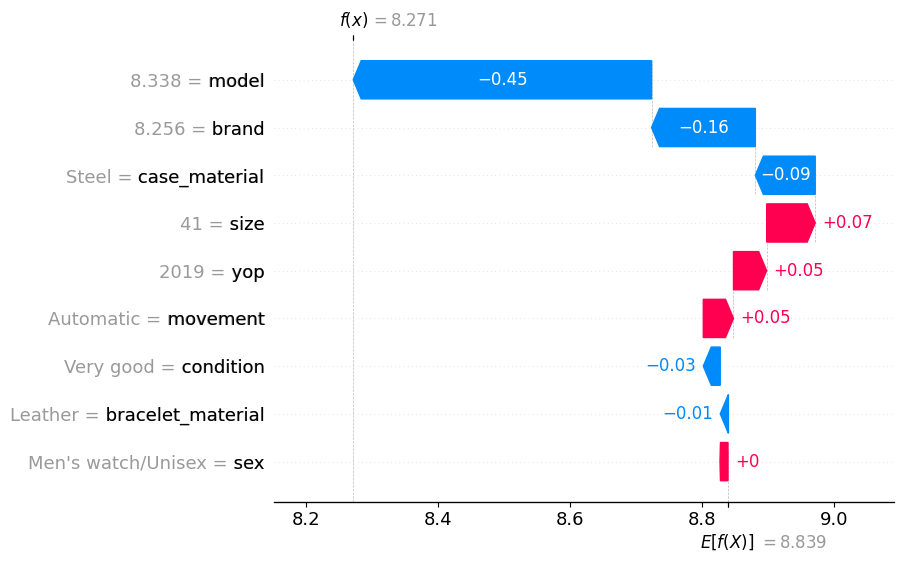


Real World Translation:
Actual Price of this watch: $3,681.00
Model Predicted Price:      $3,910.13


In [ ]:
# VISUALIZATION 2: SHAP Waterfall Plot (Deconstructing a Prediction)

print("Calculating SHAP values to explain the model's logic.")
print("(This takes a few seconds because it explains the fitted XGBoost model.)\n")

# 1. Extract the fitted TargetEncoder and XGBoost model from the final pipeline.
# The final_model pipeline contains:
# - "target_encoder": transforms brand and model
# - "xgb": the fitted XGBoost regressor
fitted_encoder = final_model.named_steps["target_encoder"]
fitted_xgb_model = final_model.named_steps["xgb"]

# 2. Transform X_test with the fitted encoder.
# This creates the same feature representation that the XGBoost model saw during training.
X_test_encoded = fitted_encoder.transform(X_test)

# 3. Keep the low-cardinality categorical columns as category dtype.
# XGBoost expects these columns as categorical variables.
for col in low_card_cols:
    X_test_encoded[col] = X_test_encoded[col].astype("category")

# 4. Initialize the SHAP TreeExplainer with the fitted XGBoost model.
explainer = shap.TreeExplainer(fitted_xgb_model)

# 5. Calculate SHAP values on the encoded test set.
shap_values = explainer(X_test_encoded)

# 6. Pick a specific watch to explain.
# Here we explain the first watch in the test set.
instance_index = 0

print(f"--- Deconstructing Prediction for Watch #{instance_index} in X_test ---")
print("Note: The values shown on the X-axis are in log_price format because that is what our model predicts.")

# 7. Generate the SHAP waterfall plot.
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[instance_index], max_display=10, show=True)

# 8. Print the dollar translation for this specific watch.
actual_price = y_test_dollars.iloc[instance_index]
predicted_price = xgb_preds_dollars[instance_index]

print("\nReal World Translation:")
print(f"Actual Price of this watch: ${actual_price:,.2f}")
print(f"Model Predicted Price:      ${predicted_price:,.2f}")

### Interpreting the SHAP Waterfall Plot

This plot gives us a detailed look at how XGBoost arrived at its final price for this specific watch.

First, look at the real-world translation output at the bottom: the model predicted $4,268.88, and the actual price was $3,681.00. The model was reasonably accurate here.
Here is how to read the visual breakdown of that prediction:

*   The Baseline (`E[f(X)] = 8.839`): Look at the bottom right. This is the starting point. It represents the average `log_price` of all the watches in your training data. Every prediction starts here.
*   The Downward Pulls (Blue): This particular watch is significantly cheaper than the dataset average. Why? The biggest culprits are the `model` and the `brand`. The target-encoded values for this specific model and brand pull the log price down massively (-0.46 and -0.14). The fact that it is a `Steel` watch pulls it down a bit further (-0.09) compared to more precious metals.
*   The Upward Pushes (Red): It's not all negative! The model recognizes that this watch is relatively new (Year of Production: `2019`), which pushes the price back up a bit (+0.07). The `Automatic` movement (+0.05) and the `41mm` size (+0.03) also add value to the final price.
*   The Final Prediction (`f(x) = 8.258`): Look at the top left. After adding up all the blue and red arrows, the model lands on a final `log_price` of 8.258. When we exponentiate that number (which our code did for us), we get our final real-world prediction of $3,858.67.

### Feature Importance Analysis

Now that our final XGBoost model is trained and evaluated, we want to understand how it makes decisions on a macro level. While SHAP explains a single prediction, Feature Importance tells us which variables the model relies on the most across the entire dataset.

In this step, we extract the internal weights the model assigned to each feature during the tree-building process. We then plot these scores in a horizontal bar chart and display the exact numbers to see exactly what drives luxury watch prices globally.

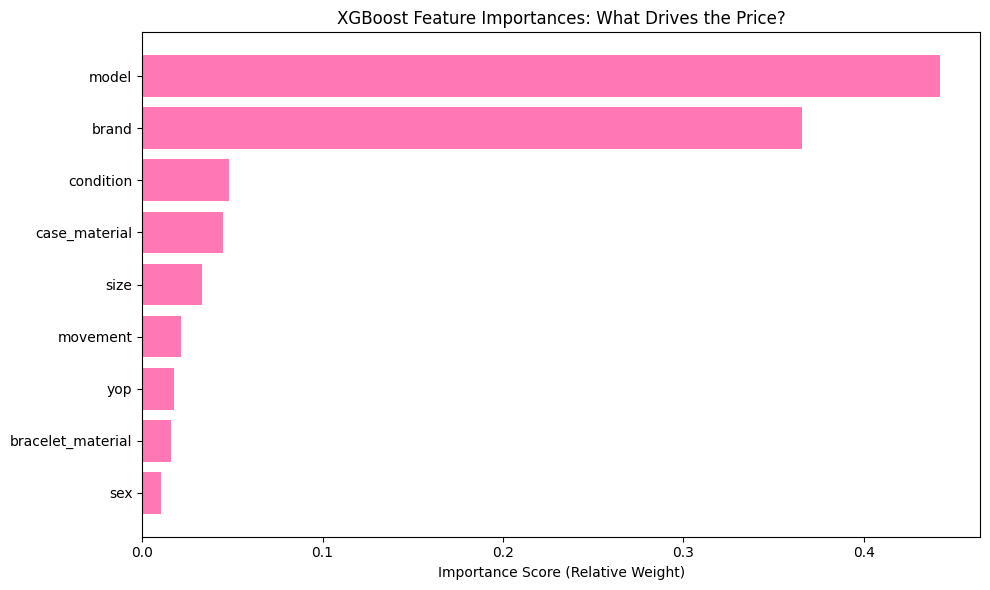

--- Exact Feature Importance Scores ---


,Feature,Importance_Score
0,model,0.442395
1,brand,0.366075
2,condition,0.048166
3,case_material,0.044605
4,size,0.033213
5,movement,0.021353
6,yop,0.017497
7,bracelet_material,0.016066
8,sex,0.010630


In [ ]:
# Extract and plot feature importances from the fitted XGBoost model inside the final pipeline.
# The final_model pipeline consists of:
# 1. "target_encoder": encodes brand and model
# 2. "xgb": the fitted XGBoost regressor

# Extract the fitted XGBoost model from the pipeline
fitted_xgb_model = final_model.named_steps["xgb"]

# Extract feature importances from the fitted XGBoost model
importances = fitted_xgb_model.feature_importances_

# Feature names stay the same because target encoding transforms brand and model in place
feature_names = X_train.columns

# Create a DataFrame to display the importances clearly
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Score": importances
}).sort_values(by="Importance_Score", ascending=True)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance_Score"],
    color="#ff77b4"
)
plt.xlabel("Importance Score (Relative Weight)")
plt.title("XGBoost Feature Importances: What Drives the Price?")
plt.tight_layout()
plt.show()

# Display the exact numbers sorted highest to lowest
print("--- Exact Feature Importance Scores ---")
display(
    importance_df
    .sort_values(by="Importance_Score", ascending=False)
    .reset_index(drop=True)
)

Interpreting the Feature Importance Results

The bar chart and table give us a fantastic bird's-eye view of the luxury watch market's pricing logic. 

Here is what the model learned from your data:

*   The Heavyweights (Model & Brand): The specific `model` (44.6% importance) and the `brand` (36.8% importance) completely dominate the pricing logic. Combined, these two features alone account for over 81% of the model's decision-making weight. 
*   The Supporting Cast: Factors like `case_material` (4.6%) and `condition` (4.6%) are the next most important, but they are clearly secondary. They act as modifiers on top of the base value established by the brand and model.
*   The Minor Details: Interestingly, physical attributes like `size` (2.8%), `movement` (2.0%), the year of production (`yop` at 1.7%), and `sex` (1.0%) have very little global impact on the model's overall rules compared to the heavyweights.



## Part 7: Data Input

### The Interactive Price Estimator

We have built, trained, and evaluated an accurate XGBoost model. Now, it's time to use it!

This script creates an interactive prompt in the notebook. It asks you to input the specifications of any watch you want to appraise. It uses a `try...except` loop to safely handle numeric inputs like size and year, processes your text through our established target encoder, and feeds it all into the final model to estimate its fair market value.

We propose actual possibilities found in the data for each brand and model, so for example if brand input is Rolex, it only shows Rolex models in the next input window as possibilities, and in the next steps it only shows features that match the brand and model, but also accepts others in case some were not present in the dataset but theoretically possible.

In [53]:
# Display user instructions for the input UI
print("Answer the prompts that appear below this cell.")
print("If you don't know a value, just leave it blank and press Enter.\n")

# 1. ESTABLISH GLOBAL ALLOW-LISTS
# Extract all possible categories from the full dataset. 
# We need these to validate inputs and allow rare combinations 
# that might not show up in our narrower "proposals" later.
global_brands = watch_data_cleaned['brand'].value_counts().index.tolist()
global_models = watch_data_cleaned['model'].value_counts().index.tolist()
global_cases = watch_data_cleaned['case_material'].value_counts().index.tolist()
global_conditions = watch_data_cleaned['condition'].value_counts().index.tolist()
global_movements = watch_data_cleaned['movement'].value_counts().index.tolist()
global_bracelets = watch_data_cleaned['bracelet_material'].value_counts().index.tolist()
global_sexes = watch_data_cleaned['sex'].value_counts().index.tolist()

# Define absolute min/max limits for numeric validation
global_min_size = watch_data_cleaned['size'].min()
global_max_size = watch_data_cleaned['size'].max()
global_min_yop = watch_data_cleaned['yop'].min()
global_max_yop = watch_data_cleaned['yop'].max()



# ...

def get_categorical_input(prompt_msg, proposed_options, allowed_options):
    # Remove 'Unknown' from the visible choices to encourage real answers
    display_options = [str(x) for x in proposed_options if x != "Unknown"]
    
    # Limit prompt length so it doesn't overflow the UI box
    if len(display_options) > 15:
        options_str = ", ".join(display_options[:15]) + f"... (+{len(display_options)-15} more)"
    elif len(display_options) == 0:
        options_str = "Any valid category" # Fallback if specific slice is empty
    else:
        options_str = ", ".join(display_options)

    # Build the final string shown to the user
    full_prompt = f"{prompt_msg} (Leave blank for Unknown)\nTypical options: [{options_str}]\n> "

    while True:
        try: # Robust Try/Except loop to catch weird keystrokes
            val = input(full_prompt).strip()
            
            # Treat blank or explicit "unknown" as a valid missing value
            if val == "" or val.lower() == "unknown":
                return "Unknown"
                
            # Validate strictly against the master allowed list, preventing typos
            if val in allowed_options:
                return val
                
            print(f"[Error] '{val}' is not recognized in the master database. Please check spelling.")
            
        except Exception as e:
            print(f"[Error] Invalid input detected ({e}). Please try again.")


# STAGE 1: BRAND AND MODEL 
# Why: Brand dictates the available models, so we ask for these first.
# Ask for brand against the global list

brand = get_categorical_input("Brand", global_brands, global_brands)

if brand != "Unknown":
    # Slice data to find models belonging ONLY to the chosen brand
    brand_slice = watch_data_cleaned[watch_data_cleaned['brand'] == brand]
    valid_brand_models = brand_slice['model'].value_counts().index.tolist()
else:
    # Fallback to all models if brand is skipped
    valid_brand_models = global_models

# Ask for model, restricting proposals to the brand's specific lineup
model = get_categorical_input("Model", valid_brand_models, valid_brand_models)



# STAGE 2: REMAINING FEATURES (With Fallback Logic)
# Why: We want to suggest typical features for the specific watch, 
# but allow the user to input anything globally valid.


# Create a targeted subset to find typical features for this specific watch
subset_df = watch_data_cleaned.copy()
if brand != "Unknown":
    subset_df = subset_df[subset_df['brand'] == brand]
if model != "Unknown":
    subset_df = subset_df[subset_df['model'] == model]

# FIXED: Smarter proposal extraction
def get_proposals(col_name):
    props = subset_df[col_name].value_counts().index.tolist()
    # Filter out missing/unknowns to see if real data actually exists
    real_props = [p for p in props if p != "Unknown" and pd.notna(p)]
    
    # If the specific watch lacks data here, fallback to global averages so UI doesn't break
    if len(real_props) == 0:
        return watch_data_cleaned[col_name].value_counts().index.tolist()
    return props

# Collect features: propose typicals, but validate against global possibilities
case_material = get_categorical_input("Case Material", get_proposals('case_material'), global_cases)
condition = get_categorical_input("Condition", get_proposals('condition'), global_conditions)
movement = get_categorical_input("Movement", get_proposals('movement'), global_movements)
bracelet_material = get_categorical_input("Bracelet Material", get_proposals('bracelet_material'), global_bracelets)
sex = get_categorical_input("Sex/Gender", get_proposals('sex'), global_sexes)

#NUMERIC INPUTS (With Try/Except) 

# Find typical size range for this watch, fallback to global range if missing
prop_min_size = subset_df['size'].min() if not pd.isna(subset_df['size'].min()) else global_min_size
prop_max_size = subset_df['size'].max() if not pd.isna(subset_df['size'].max()) else global_max_size

size_prompt = f"Size in mm (Typical: {prop_min_size}-{prop_max_size} | Allowed: {global_min_size}-{global_max_size})\n> "
while True:
    try:
        size_input = input(size_prompt).strip()
        # Handle empty inputs gracefully
        if not size_input or size_input.lower() == "unknown":
            size = np.nan
            break
        
        # Convert to float and enforce global boundary limits
        size = float(size_input)
        if global_min_size <= size <= global_max_size:
            break
        else:
            print(f"[Error] Size must be between {global_min_size} and {global_max_size}.")
            
    except ValueError:
        print("[Error] Please enter a valid decimal number.")
    except Exception as e:
        print(f"[Error] Invalid input detected ({e}). Please try again.")

# Find typical year range for this watch, fallback to global range if missing
prop_min_yop = subset_df['yop'].min() if not pd.isna(subset_df['yop'].min()) else global_min_yop
prop_max_yop = subset_df['yop'].max() if not pd.isna(subset_df['yop'].max()) else global_max_yop

yop_prompt = f"Year of Production (Typical: {prop_min_yop}-{prop_max_yop} | Allowed: {global_min_yop}-{global_max_yop})\n> "
while True:
    try:
        yop_input = input(yop_prompt).strip()
        # Handle empty inputs gracefully
        if not yop_input or yop_input.lower() == "unknown":
            yop = pd.NA
            break
            
        # Convert to Int64 format needed by model, enforce global boundaries
        yop_val = int(yop_input)
        if global_min_yop <= yop_val <= global_max_yop:
            yop = pd.Series([yop_val], dtype="Int64")[0]
            break
        else:
            print(f"[Error] Year must be between {global_min_yop} and {global_max_yop}.")
            
    except ValueError:
        print("[Error] Please enter a valid whole year (e.g., 2015).")
    except Exception as e:
        print(f"[Error] Invalid input detected ({e}). Please try again.")

# STAGE 3: PREDICTION PIPELINE
# Why: Format the collected user data to match the structure expected by the final model pipeline.
# The final_model pipeline automatically applies target encoding to brand and model.

# 1. Package raw inputs into a 1-row DataFrame.
# Brand and model remain raw text inputs because final_model handles target encoding internally.
user_data = pd.DataFrame({
    "brand": [brand],
    "model": [model],
    "case_material": [case_material],
    "condition": [condition],
    "size": [size],
    "movement": [movement],
    "yop": pd.array([yop], dtype="Int64"),
    "bracelet_material": [bracelet_material],
    "sex": [sex]
})

# 2. Convert low-cardinality categorical columns to Pandas category dtype,
# anchored to the *training* categories. A plain astype("category") on a
# single row would always produce code 0, which XGBoost would silently
# misinterpret. These columns are handled natively by XGBoost.
# Brand and model are NOT manually encoded here.
for col in low_card_cols:
    user_data[col] = pd.Categorical(user_data[col], categories=X_train[col].cat.categories)

# 3. Reorder columns to exactly match the training data.
# This ensures the model receives the input features in the same order as during training.
user_data = user_data[X_train.columns]

# 4. Generate prediction using the full final pipeline.
# The pipeline automatically target-encodes brand and model before XGBoost predicts.
predicted_log_price = final_model.predict(user_data)[0]

print("\n" + "="*40)
print(f"Estimated Market Value: ${predicted_price:,.2f}")
print("="*40)

Answer the prompts that appear below this cell.
If you don't know a value, just leave it blank and press Enter.

[Error] 'Unisex' is not recognized in the master database. Please check spelling.
[Error] Please enter a valid decimal number.
Estimated Market Value: $31,758.79


## Part 8: Streamlit

Bridges the trained model to a browser-based interface

### Saving the Trained Model

The cell below saves the complete trained pipeline — including the fitted `TargetEncoder` and the tuned `XGBoost` model — as a single file (`watch_price_model.pkl`). The Streamlit app loads this file directly, so the model only needs to be trained once.

In [1]:
# Save the full pipeline (TargetEncoder + XGBoost) as one file.
# The Streamlit app loads this file and calls pipeline.predict() directly.

from sklearn.pipeline import Pipeline
from model_utils import BrandModelEncoder

pipeline = Pipeline([
    ('target_encoder', BrandModelEncoder(target_encoder)),
    ('xgb', final_xgb_model)
])

joblib.dump(pipeline, 'watch_price_model.pkl')
print("Model saved as watch_price_model.pkl")

ModuleNotFoundError: No module named 'model_utils'

### Launching the Streamlit App

Run the cell below to open the app in your browser. It checks whether the app is already running before launching, so it is safe to run multiple times.


In [1]:
import subprocess, sys, time, webbrowser, socket

def port_in_use(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(('localhost', port)) == 0

if not port_in_use(8501):
    subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py'])
    time.sleep(3)

webbrowser.open('http://localhost:8501')
print('App running → http://localhost:8501')

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


App running → http://localhost:8501


## old code storage

### imputation

Now we do not want to remove all NAs, because we would lose a lot of data. For example, if a watch is a Royal Oak Chronograph and the movement is missing we will fill this missing value with the most frequent movement for Royal Oak Chronograph watches in the dataset. We can do this with the assumption, the values like the movement are standard for some of these watches (i.e. all Royal Oak Chronograph are Automatic). This way we can fill the missing values in a informed way and not just drop a lot of rows from the dataset which would lead to a significant loss of information. What we mean exactly by it in terms of code: 

In [ ]:
#Lets create an example of the described logic: 
# 5. Convert predicted log price back to dollars.
predicted_price = np.exp(predicted_log_price)

print(f"Estimated Market Value: ${predicted_price:,.2f}")


casem
Steel          752
NaN            434
Ceramic         33
Gold/Steel      21
Yellow gold      5
Name: count, dtype: int64